In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

In [2]:
import numpy as np
import pandas as pd

def generate_tuned_cars_dataset(n_samples: int = 2000, 
                                seed: int = 42) -> pd.DataFrame:
    """
    Генерирует датасет для задачи бинарной классификации:
    определение модифицированных (тюнингованных) автомобилей
    по телематическим данным.

    Классы сбалансированы (50/50).
    Два сигнальных признака — max_intake_pressure и mean_exhaust_temp.

    Параметры:
        n_samples : количество объектов
        seed      : сид генератора

    Возвращает:
        pd.DataFrame с 40 предикторами и целевой переменной is_tuned
    """

    rng = np.random.default_rng(seed)

    # ---------- Базовые признаки (шум) ----------
    # Многие признаки — просто шум с разными средними и дисперсиями,
    # не зависящие от таргета

    n = n_samples

    data = {}

    # Список признаков: (название, среднее, std)
    noise_features = {
        # Обороты и скорость
        'mean_engine_rpm':       (2500.0, 400.0),
        'max_engine_rpm':        (6000.0, 800.0),
        'mean_speed':            (60.0, 15.0),
        'max_speed':             (180.0, 30.0),
        'mean_trip_duration':    (25.0, 10.0),
        'mean_trip_distance':    (22.0, 12.0),
        'n_trips_per_day':       (3.5, 1.5),

        # Температуры
        'mean_coolant_temp':     (90.0, 4.0),
        'mean_intake_temp':      (35.0, 8.0),
        'mean_oil_temp':         (100.0, 8.0),
        'mean_exhaust_temp':     (600.0, 80.0),  # будет сигнальным

        # Давления
        'mean_oil_pressure':     (300.0, 40.0),
        'mean_boost_target':     (120.0, 20.0),
        'mean_fuel_pressure':    (4000.0, 300.0),
        'mean_intake_pressure':  (95.0, 12.0),   # среднее — почти атмосферное,
                                                  # а вот максимум — сигнальный

        # Топливо и зажигание
        'mean_fuel_trim_long':   (0.0, 5.0),
        'mean_fuel_trim_short':  (0.0, 3.0),
        'mean_ignition_timing':  (12.0, 4.0),    # будет сигнальным
        'mean_maf_rate':         (45.0, 15.0),
        'mean_afr':              (14.7, 0.3),
        'mean_fuel_consumption': (9.0, 2.0),

        # Нагрузки и педали
        'mean_engine_load':      (45.0, 15.0),
        'max_engine_load':       (80.0, 10.0),
        'mean_throttle_pos':     (25.0, 10.0),
        'mean_accel_pedal_pos':  (20.0, 8.0),
        'max_accel_pedal_pos':   (70.0, 15.0),
        'mean_brake_pedal_pos':  (12.0, 5.0),

        # Поведение
        'n_hard_accelerations':  (45.0, 20.0),
        'n_hard_brakings':       (38.0, 18.0),

        # Датчики
        'mean_lambda_sensor_1':  (0.7, 0.1),
        'mean_lambda_sensor_2':  (0.6, 0.1),
        'mean_alternator_voltage': (14.2, 0.4),

        # Прочее
        'mean_knock_retard':     (0.0, 2.0),     # будет сигнальным
        'max_knock_retard':      (4.0, 2.0),
    }
    # Проверка: 35 шумовых (40 всего - 5 сигнальных = 35)
    # Сейчас в словаре 40? Проверим: 1+1+5+1+1+1+1 + 4+1 + 3+1+1 + 7+1 + 5+1 + 1 = ... 
    # Лучше подсчитаем программно ниже

    for name, (mu, sigma) in noise_features.items():
        data[name] = rng.normal(mu, sigma, n)

    # ---------- Таргет ----------
    # Сбалансированные классы: 50% тюнингованных
    tuned = np.zeros(n, dtype=int)
    tuned[rng.choice(n, size=n//2, replace=False)] = 1
    data['is_tuned'] = tuned

    # ---------- Сигнальные признаки ----------
    # Базовые значения для стандартных авто
    # Для тюнингованных — сдвигаем средние в характерную сторону

    is_tuned = tuned.astype(bool)

    # Сигнал 1: max_intake_pressure (давление наддува)
    # Стандарт: 130-160 кПа, тюнинг: 170-210 кПа
    base_intake = rng.normal(145.0, 15.0, n)
    boost = np.where(is_tuned, 45.0, 5.0)  # добавка для тюнинга
    data['max_intake_pressure'] = base_intake + boost * rng.uniform(0.8, 1.2, n)

    # Сигнал 2: mean_exhaust_temp (температура выхлопа)
    # Стандарт: 550-650°C, тюнинг: 620-760°C
    base_exhaust = rng.normal(600.0, 35.0, n)
    exhaust_boost = np.where(is_tuned, 100.0, 0.0)
    data['mean_exhaust_temp'] = base_exhaust + exhaust_boost * rng.uniform(0.7, 1.3, n)

    # Сигнал 3: max_coolant_temp (температура ОЖ)
    # Стандарт: 108-112°C, тюнинг: 112-118°C
    base_coolant = rng.normal(109.0, 2.5, n)
    coolant_boost = np.where(is_tuned, 5.0, 0.0)
    data['max_coolant_temp'] = base_coolant + coolant_boost * rng.uniform(0.5, 1.5, n)

    # Сигнал 4: mean_ignition_timing (угол опережения зажигания)
    # Тюнинг обычно сдвигает вперёд: стандарт 8-12°, тюнинг 12-16°
    base_timing = rng.normal(10.0, 2.0, n)
    timing_boost = np.where(is_tuned, 4.0, 0.0)
    data['mean_ignition_timing'] = base_timing + timing_boost * rng.uniform(0.6, 1.4, n)

    # Сигнал 5: mean_knock_retard (детонационная коррекция)
    # Тюнинг ближе к детонации: стандарт 0-1°, тюнинг -3 до -6°
    base_knock = rng.normal(-0.5, 1.0, n)
    knock_shift = np.where(is_tuned, -3.5, 0.0)
    data['mean_knock_retard'] = base_knock + knock_shift * rng.uniform(0.7, 1.3, n)

    # ---------- Собираем датафрейм ----------
    df = pd.DataFrame(data)

    # Порядок колонок: сначала все предикторы, потом таргет
    feature_cols = [c for c in df.columns if c != 'is_tuned']
    df = df[feature_cols + ['is_tuned']]

    return df


# Пример использования
if __name__ == "__main__":
    df = generate_tuned_cars_dataset(n_samples=2000, seed=42)
    print(df.shape)
    print(df.head())
    print("\nРаспределение таргета:")
    print(df['is_tuned'].value_counts(normalize=True))

    # Пары признаков для визуализации
    print("\nСредние значения сигнальных признаков по классам:")
    signal_cols = ['max_intake_pressure', 'mean_exhaust_temp', 
                   'max_coolant_temp', 'mean_ignition_timing', 'mean_knock_retard']
    print(df.groupby('is_tuned')[signal_cols].mean().round(2))


(2000, 37)
   mean_engine_rpm  max_engine_rpm  mean_speed   max_speed  \
0      2621.886832     5638.439216   63.798068  186.753502   
1      2084.006358     5467.297831   73.428276  178.399711   
2      2800.180478     6347.207859   64.099819  205.921309   
3      2876.225887     6201.483532   93.582475  198.201995   
4      1719.585925     4876.166762   81.446812   90.425324   

   mean_trip_duration  mean_trip_distance  n_trips_per_day  mean_coolant_temp  \
0           28.336023           24.115324         3.035319          89.273395   
1           37.363432           32.789482         3.590354          94.280975   
2           37.158294            4.332753         1.638866          98.913838   
3           20.490432           18.576422         1.418370          90.718613   
4           26.940174           31.949840         3.773447          89.973711   

   mean_intake_temp  mean_oil_temp  ...  n_hard_accelerations  \
0         24.420092     105.090119  ...             28.997710   

In [3]:
df

,mean_engine_rpm,max_engine_rpm,mean_speed,max_speed,mean_trip_duration,mean_trip_distance,n_trips_per_day,mean_coolant_temp,mean_intake_temp,mean_oil_temp,...,n_hard_accelerations,n_hard_brakings,mean_lambda_sensor_1,mean_lambda_sensor_2,mean_alternator_voltage,mean_knock_retard,max_knock_retard,max_intake_pressure,max_coolant_temp,is_tuned
0,2621.886832,5638.439216,63.798068,186.753502,28.336023,24.115324,3.035319,89.273395,24.420092,105.090119,...,28.997710,33.522611,0.751880,0.678267,14.410536,-1.671737,5.209816,144.718687,113.531272,0
1,2084.006358,5467.297831,73.428276,178.399711,37.363432,32.789482,3.590354,94.280975,46.113177,112.636753,...,23.689083,17.835006,0.664165,0.568872,14.483821,-0.376140,6.257196,169.866734,109.130655,0
2,2800.180478,6347.207859,64.099819,205.921309,37.158294,4.332753,1.638866,98.913838,32.214070,94.649670,...,39.291031,57.386499,0.529611,0.752767,14.483974,-3.990013,3.494602,194.923109,113.945046,1
3,2876.225887,6201.483532,93.582475,198.201995,20.490432,18.576422,1.418370,90.718613,34.425407,95.636375,...,64.239806,33.286907,0.693004,0.499073,14.336973,-0.848459,-1.375821,167.324543,107.714233,0
4,1719.585925,4876.166762,81.446812,90.425324,26.940174,31.949840,3.773447,89.973711,37.268281,98.329066,...,48.428484,42.416559,0.581558,0.431915,14.765339,-0.339627,3.486534,184.892297,108.335597,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2656.804375,5456.969461,37.952137,164.827737,41.201061,25.391905,4.261945,89.059624,34.329450,114.118630,...,47.351119,14.926338,0.705861,0.679357,14.719389,-1.710603,3.790417,153.989166,106.430972,0
1996,2621.534970,6809.328331,63.358391,241.214802,24.368202,20.453101,3.860565,95.816098,37.726560,93.503050,...,33.582785,32.582348,0.731183,0.639799,13.931951,-3.726878,4.624317,215.642497,116.325599,1
1997,2463.383992,5803.423381,84.201614,140.395961,25.852488,32.049722,3.913610,92.852838,36.305883,105.130497,...,43.067386,18.196889,0.629498,0.567062,14.168511,-3.339735,5.214591,147.221218,107.431399,0
1998,2287.671269,5480.317032,63.047497,192.777669,36.247442,10.798930,3.331150,88.650938,21.315671,104.248342,...,55.413167,51.052987,0.678521,0.568906,13.887457,-2.706421,5.344313,209.388189,108.101109,1


k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


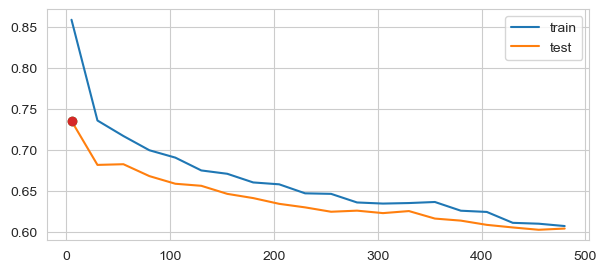

Дефолтный скор: 0.735
Максимальный скор: 0.735 при k = 5
Прирост скора: 0.0


In [4]:
X = df.drop(columns = ['is_tuned'])
y = df['is_tuned']

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


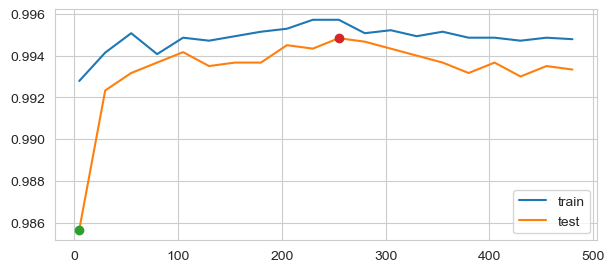

Дефолтный скор: 0.9857
Максимальный скор: 0.9948 при k = 255
Прирост скора: 0.0092


In [6]:
X = df.drop(columns = ['is_tuned'])
y = df['is_tuned']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

k = 5
k = 30
k = 55
k = 80
k = 105
k = 130
k = 155
k = 180
k = 205
k = 230
k = 255
k = 280
k = 305
k = 330
k = 355
k = 380
k = 405
k = 430
k = 455
k = 480


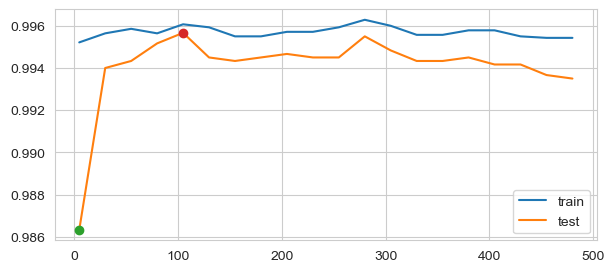

Дефолтный скор: 0.9863
Максимальный скор: 0.9957 при k = 105
Прирост скора: 0.0093


In [7]:
X = df.drop(columns = ['is_tuned'])
y = df['is_tuned']

scaler = StandardScaler()
X = scaler.fit_transform(X)

horisontal_ax = []

Accuracy_train_list = []
Accuracy_test_list = []

for k in range(5, round(25*len(X)/100), 25):
    

    print('k =', k)
    horisontal_ax.append(k)

    accuracy_train_list = []
    accuracy_test_list = []

    for seed in range(10):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

        model = KNeighborsClassifier(k, metric='manhattan')
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)

        accuracy_train_list.append(accuracy_train)
        accuracy_test_list.append(accuracy_test)

    Accuracy_train_list.append(np.array(accuracy_train_list).mean())
    Accuracy_test_list.append(np.array(accuracy_test_list).mean())

max_score_index = np.argmax(np.array(Accuracy_test_list))

plt.figure(figsize=(7, 3))
plt.grid(True)
plt.plot(horisontal_ax, Accuracy_train_list, label = 'train')
plt.plot(horisontal_ax, Accuracy_test_list, label = 'test')
plt.plot(horisontal_ax[0], Accuracy_test_list[0], 'o')
plt.plot(horisontal_ax[max_score_index], Accuracy_test_list[max_score_index], 'o')
plt.legend()
plt.show()

# print('Последовательность скоров:')
# print(list(np.array(Accuracy_test_list).round(4)))
print('Дефолтный скор:', round(np.array(Accuracy_test_list)[0], 4))
print('Максимальный скор:', round(np.array(Accuracy_test_list).max(), 4), 'при k =', max_score_index*25 + 5)
print('Прирост скора:', (np.array(Accuracy_test_list).max() - np.array(Accuracy_test_list)[0]).round(4))

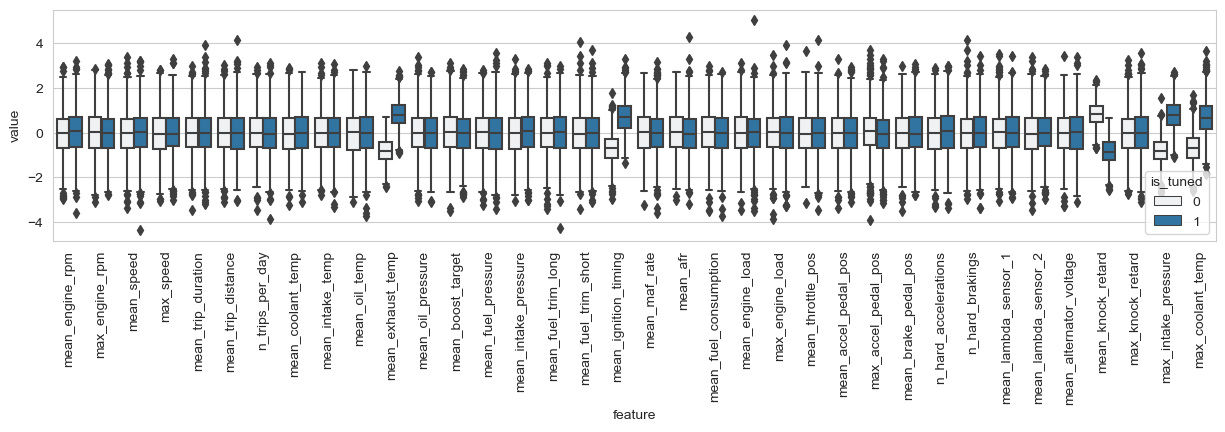

In [9]:
feature_long = pd.DataFrame(columns = ['feature', 'value', 'is_tuned'])
for col in df.columns[:-1]:
    d = pd.DataFrame(columns = ['feature', 'value', 'is_tuned'])
    d['feature'] = [col]*len(df)
    d['value'] = (df[col] - df[col].mean())/df[col].std()
    d['is_tuned'] = df['is_tuned']
    feature_long = pd.concat([feature_long, d], ignore_index=True)


plt.figure(figsize=(15, 3))
sns.boxplot(data=feature_long, x='feature', y='value', hue='is_tuned', color = 'C0')
plt.xticks(rotation=90)
plt.show()

In [10]:
df

,mean_engine_rpm,max_engine_rpm,mean_speed,max_speed,mean_trip_duration,mean_trip_distance,n_trips_per_day,mean_coolant_temp,mean_intake_temp,mean_oil_temp,...,n_hard_accelerations,n_hard_brakings,mean_lambda_sensor_1,mean_lambda_sensor_2,mean_alternator_voltage,mean_knock_retard,max_knock_retard,max_intake_pressure,max_coolant_temp,is_tuned
0,2621.886832,5638.439216,63.798068,186.753502,28.336023,24.115324,3.035319,89.273395,24.420092,105.090119,...,28.997710,33.522611,0.751880,0.678267,14.410536,-1.671737,5.209816,144.718687,113.531272,0
1,2084.006358,5467.297831,73.428276,178.399711,37.363432,32.789482,3.590354,94.280975,46.113177,112.636753,...,23.689083,17.835006,0.664165,0.568872,14.483821,-0.376140,6.257196,169.866734,109.130655,0
2,2800.180478,6347.207859,64.099819,205.921309,37.158294,4.332753,1.638866,98.913838,32.214070,94.649670,...,39.291031,57.386499,0.529611,0.752767,14.483974,-3.990013,3.494602,194.923109,113.945046,1
3,2876.225887,6201.483532,93.582475,198.201995,20.490432,18.576422,1.418370,90.718613,34.425407,95.636375,...,64.239806,33.286907,0.693004,0.499073,14.336973,-0.848459,-1.375821,167.324543,107.714233,0
4,1719.585925,4876.166762,81.446812,90.425324,26.940174,31.949840,3.773447,89.973711,37.268281,98.329066,...,48.428484,42.416559,0.581558,0.431915,14.765339,-0.339627,3.486534,184.892297,108.335597,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2656.804375,5456.969461,37.952137,164.827737,41.201061,25.391905,4.261945,89.059624,34.329450,114.118630,...,47.351119,14.926338,0.705861,0.679357,14.719389,-1.710603,3.790417,153.989166,106.430972,0
1996,2621.534970,6809.328331,63.358391,241.214802,24.368202,20.453101,3.860565,95.816098,37.726560,93.503050,...,33.582785,32.582348,0.731183,0.639799,13.931951,-3.726878,4.624317,215.642497,116.325599,1
1997,2463.383992,5803.423381,84.201614,140.395961,25.852488,32.049722,3.913610,92.852838,36.305883,105.130497,...,43.067386,18.196889,0.629498,0.567062,14.168511,-3.339735,5.214591,147.221218,107.431399,0
1998,2287.671269,5480.317032,63.047497,192.777669,36.247442,10.798930,3.331150,88.650938,21.315671,104.248342,...,55.413167,51.052987,0.678521,0.568906,13.887457,-2.706421,5.344313,209.388189,108.101109,1


In [11]:
# df.to_csv('data/tuning.csv', index = False)